**Step 0 : Importing and Reading Data**

In [47]:
# Basic Imports
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
# plt.set_option('max_columns', 200)

# Machine Learning imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from xgboost import XGBClassifier

In [48]:
df = pd.read_csv('/content/synthetic_fraud_dataset.csv')

**Step 1 : Data Understanding**

Dataframe shape

head and tail

dtypes

describe

In [49]:
df.shape

(10000, 10)

In [50]:
df.head(20)

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0
5,2183,944,97.108625,POS,Clothing,DE,17,0.235399,0.105454,0
6,1919,829,166.209262,Online,Travel,UK,12,0.115906,0.223718,0
7,3479,845,96.512637,Online,Grocery,US,7,0.082250,0.034023,0
8,6796,129,83.338701,QR,Food,DE,16,0.021774,0.279598,0
9,5129,249,89.695731,QR,Grocery,UK,6,0.095353,0.136336,0


In [51]:
# Checking Target distribution
print(df['is_fraud'].value_counts())

# Percentage of Fraud and Non Fraudulent activities
print(df['is_fraud'].value_counts(normalize=True))

is_fraud
0    9500
1     500
Name: count, dtype: int64
is_fraud
0    0.95
1    0.05
Name: proportion, dtype: float64


In [52]:
df.columns

Index(['transaction_id', 'user_id', 'amount', 'transaction_type',
       'merchant_category', 'country', 'hour', 'device_risk_score',
       'ip_risk_score', 'is_fraud'],
      dtype='object')

In [53]:
df.dtypes

,0
transaction_id,int64
user_id,int64
amount,float64
transaction_type,object
merchant_category,object
country,object
hour,int64
device_risk_score,float64
ip_risk_score,float64
is_fraud,int64


In [54]:
# Basic Describe
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


In [55]:
# Describe Based on Target (Fraud)
print(df.groupby('is_fraud')[['amount', 'hour']].mean())
print(df.groupby('is_fraud')[['amount', 'hour']].std())
print(df.groupby('is_fraud')[['amount', 'hour']].min())
print(df.groupby('is_fraud')[['amount', 'hour']].max())

               amount       hour
is_fraud                        
0          100.277751  14.469684
1         1657.577984  10.018000
               amount      hour
is_fraud                       
0           49.500552  5.167703
1         1818.946673  6.764110
          amount  hour
is_fraud              
0            1.0     6
1           10.0     0
                amount  hour
is_fraud                    
0           277.203251    23
1         11628.213881    23


**Step 2 : Data Preparation**

Dropping irrelevant columns and rows

Identifying duplicated columns

Renaming Columns

Feature Creation

In [56]:
# Rename Columns
df = df.rename(columns={'transaction_id' : 'Transaction_id', 'user_id' : 'User_id', 'amount' : 'Amount', 'transaction_type' : 'Transaction_Type',
       'merchant_category' : 'Merchant_Category', 'country' : 'Country', 'hour' : 'Hour', 'device_risk_score' : 'Device_risk_score', 'is_fraud' : 'Is_Fraud'})

In [57]:
df.columns

Index(['Transaction_id', 'User_id', 'Amount', 'Transaction_Type',
       'Merchant_Category', 'Country', 'Hour', 'Device_risk_score',
       'ip_risk_score', 'Is_Fraud'],
      dtype='object')

In [58]:
df.isna().sum()

,0
Transaction_id,0
User_id,0
Amount,0
Transaction_Type,0
Merchant_Category,0
Country,0
Hour,0
Device_risk_score,0
ip_risk_score,0
Is_Fraud,0


In [59]:
df.loc[df.duplicated()]

,Transaction_id,User_id,Amount,Transaction_Type,Merchant_Category,Country,Hour,Device_risk_score,ip_risk_score,Is_Fraud


In [60]:
# Check for duplicate transaction_id
df.loc[df.duplicated(subset=['Transaction_id'])].head(5)

,Transaction_id,User_id,Amount,Transaction_Type,Merchant_Category,Country,Hour,Device_risk_score,ip_risk_score,Is_Fraud


In [61]:
# Check for duplicate user_id
df.loc[df.duplicated(subset=['User_id'])].head(5)

,Transaction_id,User_id,Amount,Transaction_Type,Merchant_Category,Country,Hour,Device_risk_score,ip_risk_score,Is_Fraud
47,7710,984,26.693043,Online,Electronics,US,17,0.252184,0.102705,0
87,9711,935,952.547905,QR,Travel,UK,20,0.783611,0.985521,1
100,3556,116,84.720387,Online,Grocery,DE,6,0.101024,0.199327,0
110,6053,258,65.088888,POS,Electronics,FR,11,0.145436,0.292756,0
115,3354,920,82.757512,Online,Food,UK,23,0.293357,0.203809,0


In [62]:
# Checking an example of a duplicate
df.query('User_id == 984')

,Transaction_id,User_id,Amount,Transaction_Type,Merchant_Category,Country,Hour,Device_risk_score,ip_risk_score,Is_Fraud
18,6484,984,88.509815,QR,Travel,UK,19,0.147803,0.206480,0
47,7710,984,26.693043,Online,Electronics,US,17,0.252184,0.102705,0
780,2437,984,5.494676,Online,Clothing,DE,21,0.029862,0.054977,0
838,4310,984,71.046920,POS,Food,DE,6,0.148423,0.295478,0
1396,8731,984,105.694996,POS,Food,US,13,0.148126,0.265563,0
2263,6411,984,158.036364,Online,Electronics,FR,10,0.140750,0.162537,0
3248,4467,984,114.068707,POS,Food,US,14,0.214275,0.019599,0
5434,1104,984,128.606286,ATM,Grocery,TR,14,0.019103,0.268133,0
8340,4101,984,111.568116,Online,Electronics,DE,20,0.013852,0.241175,0
8854,9549,984,3788.538669,ATM,Travel,NG,4,0.790074,0.736917,1


In [63]:
df.columns

Index(['Transaction_id', 'User_id', 'Amount', 'Transaction_Type',
       'Merchant_Category', 'Country', 'Hour', 'Device_risk_score',
       'ip_risk_score', 'Is_Fraud'],
      dtype='object')

In [64]:
df['User_id'].value_counts()

,count
User_id,
438,21
824,21
605,21
72,21
848,20
...,...
345,3
895,3
311,3


In [65]:
df['Amount'].value_counts()

,count
Amount,
1.000000,231
10.000000,92
22.168429,41
229.289531,1
127.269474,1
...,...
151.769822,1
109.922076,1
74.333541,1


In [66]:
df['Country'].value_counts()

,count
Country,
US,2050
FR,2027
UK,1965
DE,1930
TR,1928
NG,100


**Step 3: Feature Understanding**

(Univariate analysis)

Plotting Feature Distributions

Histogram

KDE

Text(0, 0.5, 'Count')

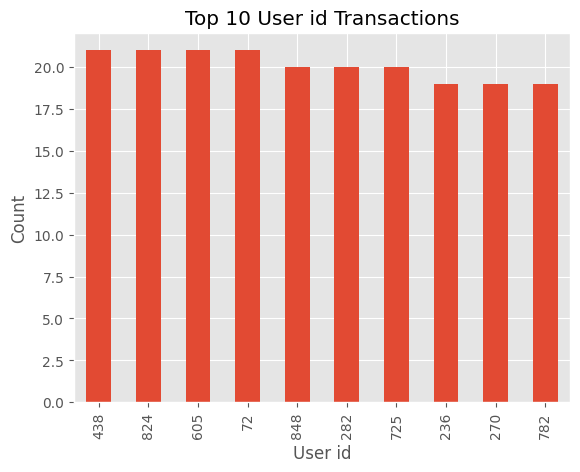

In [67]:
ax = df['User_id'].value_counts().head(10).plot(kind='bar', title='Top 10 User id Transactions')
ax.set_xlabel('User id')
ax.set_ylabel('Count')

In [68]:
df['Merchant_Category'].value_counts()

,count
Merchant_Category,
Food,2023
Travel,2015
Electronics,2007
Clothing,1982
Grocery,1973


In [69]:
df['Transaction_Type'].value_counts()

,count
Transaction_Type,
POS,2568
ATM,2529
QR,2506
Online,2397


**Step 4: Feature Relationships**

Scatterplot

Heatmap Correlation

Pairplot

Groupby comparisons

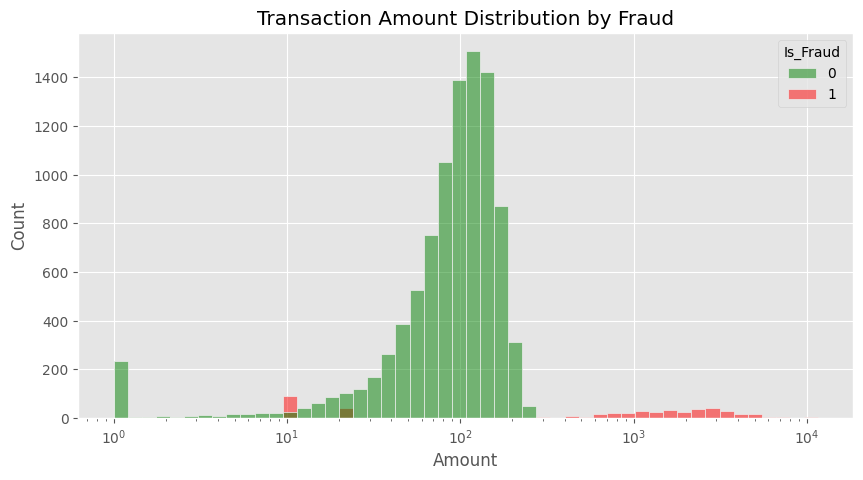

In [70]:
# Amount distribution by fraud
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Amount', hue='Is_Fraud', bins=50, log_scale=True, palette=['green','red'])
plt.title("Transaction Amount Distribution by Fraud")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

Findings from graph is *Most transactions are normal and for medium amounts of money. Fraudulent transactions don’t happen often, but when they do, they are more likely to be high-value.*

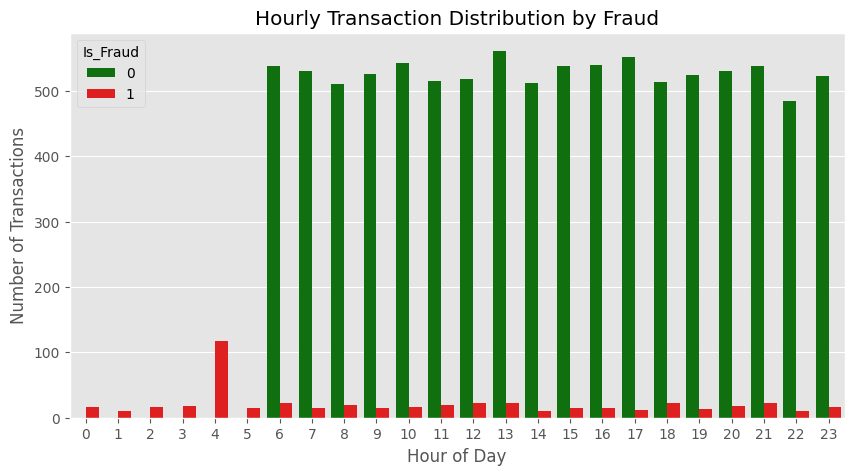

In [71]:
# Count of transactions per hour by Fraud
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Hour', hue='Is_Fraud', palette=['green', 'red'])
plt.title("Hourly Transaction Distribution by Fraud")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()

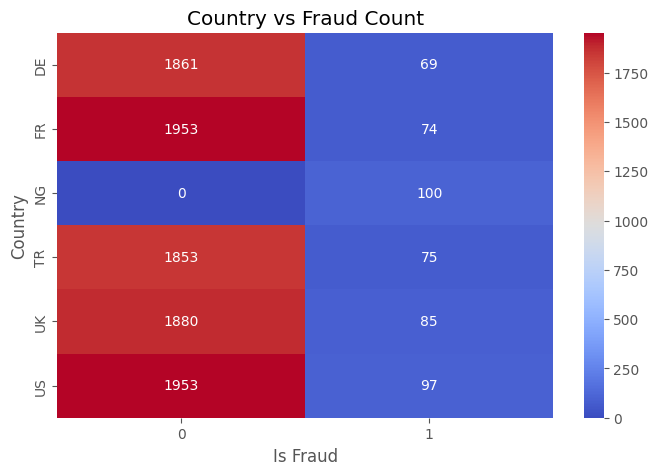

In [72]:
# Pivot table: Country vs Fraud
country_fraud = df.pivot_table(index= 'Country', columns='Is_Fraud', values='Transaction_id', aggfunc='count').fillna(0)

# Plot heatmap
plt.figure(figsize=(8,5))
sns.heatmap(country_fraud, annot=True, fmt='g', cmap = 'coolwarm')
plt.title("Country vs Fraud Count")
plt.xlabel("Is Fraud")
plt.ylabel("Country")
plt.show()


Distribution of countries based on Fraud shows that NG never had a legitimate transaction made there. And also has the most fraudulent transactions at 100 counts

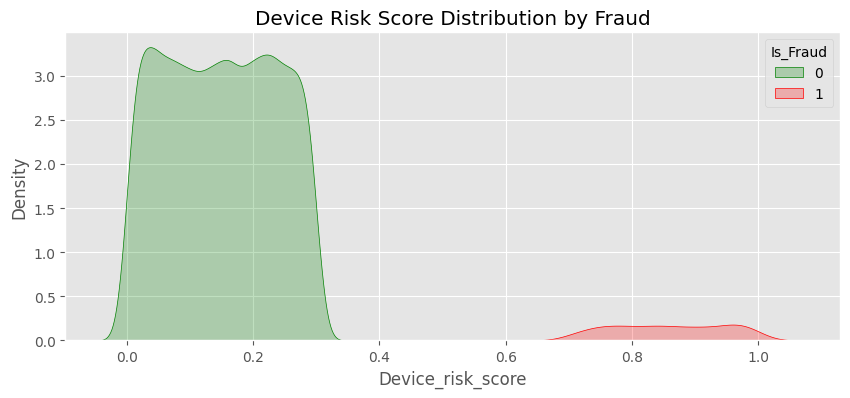

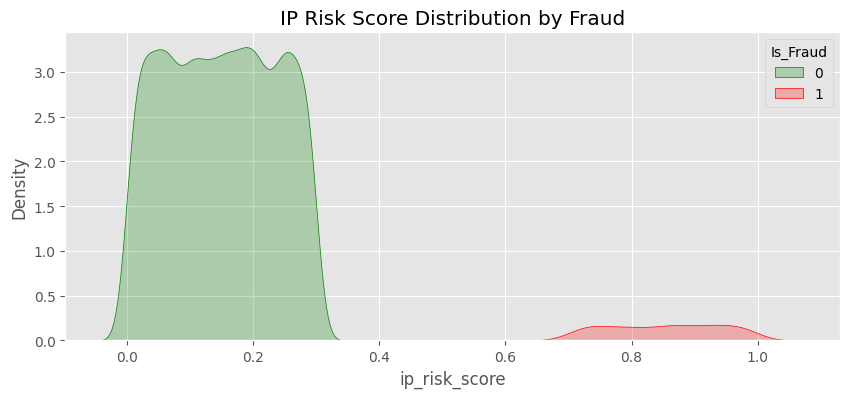

In [73]:
# Device risk score
plt.figure(figsize=(10,4))
sns.kdeplot(data=df, x='Device_risk_score', hue='Is_Fraud', fill=True, palette=['green', 'red'])
plt.title("Device Risk Score Distribution by Fraud")
plt.show()

# IP risk score
plt.figure(figsize=(10,4))
sns.kdeplot(data=df, x='ip_risk_score', hue='Is_Fraud', fill=True, palette=['green', 'red'])
plt.title("IP Risk Score Distribution by Fraud")
plt.show()

In [74]:
df.columns

Index(['Transaction_id', 'User_id', 'Amount', 'Transaction_Type',
       'Merchant_Category', 'Country', 'Hour', 'Device_risk_score',
       'ip_risk_score', 'Is_Fraud'],
      dtype='object')

In [75]:
# features and target

features = ['Amount', 'Hour', 'Device_risk_score', 'ip_risk_score']
target = 'Is_Fraud'

X = df[features]
y = df[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [76]:
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



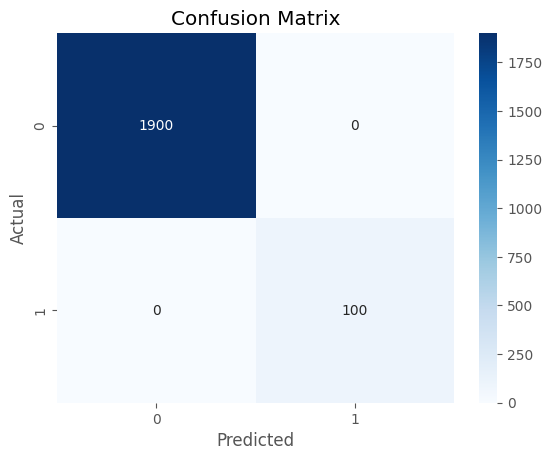

ROC-AUC: 1.0


In [77]:
# Predictions
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:,1]

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC-AUC
roc_score = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_score)

/tmp/ipython-input-2137933713.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


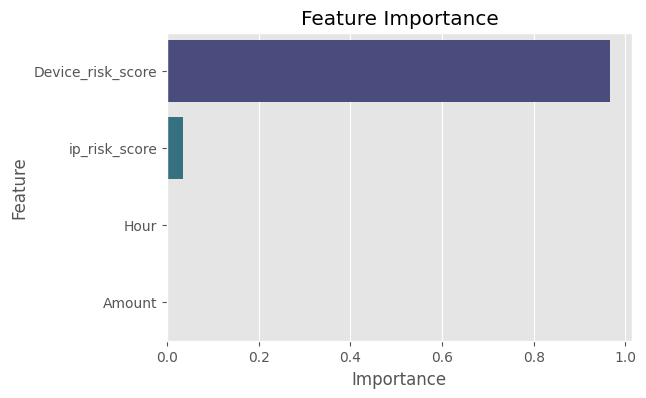

In [78]:
# Feature importance

importances = xgb.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title("Feature Importance")
plt.show()
# plt.figure(figsize=(6,4))
# sns.barplot(x='importance', y='feature', data=feat_df, palette='viridis')
# plt.title("Feature Importance")
# plt.show()

   Amount  Hour  Device_risk_score  ip_risk_score  predicted_is_fraud  \
0    1200     2               0.90           0.85                   1   
1      50    14               0.10           0.05                   0   
2    5000    23               0.95           0.90                   1   
3     300    10               0.20           0.15                   0   
4     800     1               0.80           0.75                   1   
5      20    18               0.05           0.02                   0   

  predicted_label  
0           Fraud  
1           Legit  
2           Fraud  
3           Legit  
4           Fraud  
5           Legit  


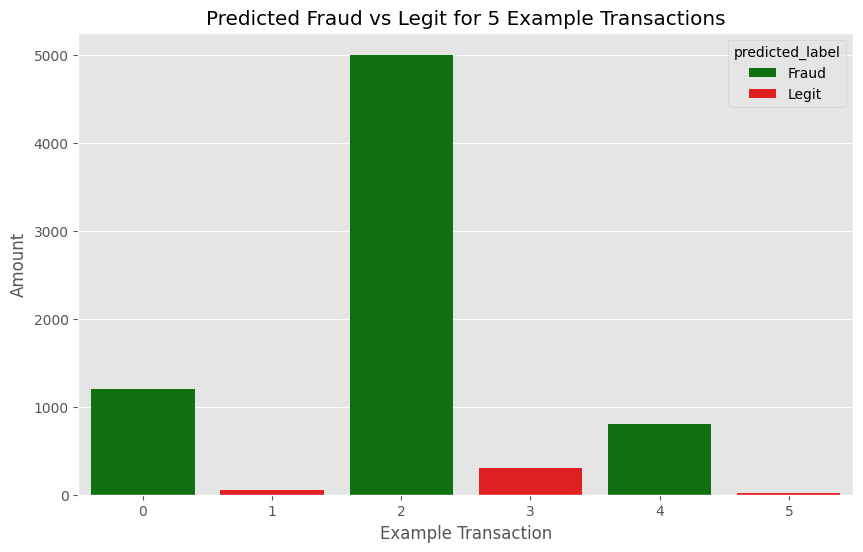

In [80]:
# Example new transactions
new_transactions = pd.DataFrame({
    'Amount': [1200, 50, 5000, 300, 800, 20],
    'Hour': [2, 14, 23, 10, 1, 18],
    'Device_risk_score': [0.9, 0.1, 0.95, 0.2, 0.8, 0.05],
    'ip_risk_score': [0.85, 0.05, 0.9, 0.15, 0.75, 0.02]
})

# Make predictions
predictions = xgb.predict(new_transactions)
new_transactions['predicted_is_fraud'] = predictions
new_transactions['predicted_label'] = new_transactions['predicted_is_fraud'].apply(lambda x: 'Fraud' if x==1 else 'Legit')

print(new_transactions)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x=new_transactions.index, y='Amount', hue='predicted_label', data=new_transactions, dodge=False, palette=['green','red'])
plt.title("Predicted Fraud vs Legit for 5 Example Transactions")
plt.xlabel("Example Transaction")
plt.ylabel("Amount")
plt.show()